# Retail Store Sales Analysis
===========================

Step 3: Exploratory Data Analysis (EDA)
---------------------------------------

Objective:
----------

Conduct descriptive and exploratory analysis to uncover patterns and trends in retail store sales data.

Analysis Approach:
------------------

1. *Univariate Analysis* – Understanding individual variable distributions  
2. *Bivariate Analysis* – Exploring relationships between two variables  
3. *Multivariate Analysis* – Identifying complex patterns and interactions  
4. *Correlation Analysis* – Measuring relationships between numerical variables  

Key Questions to Answer:
-----------------------

- Which product categories generate the highest sales?
- How do discounts affect total revenue?
- Which customer locations show higher purchase volume?
- What trends exist across months and years?

Tools Used
----------

- *Python* – Programming language for data analysis  
- *Pandas* – Data manipulation and cleaning  
- *NumPy* – Numerical computations  
- *Matplotlib* – Data visualization  
- *Seaborn* – Statistical data visualization  
- *Jupyter Notebook* – Interactive analysis and documentation


#Import Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_palette('husl')
print("All necessary libraries imported successfully!")



All necessary libraries imported successfully!


### Dataset Details

- *Source:* Retail Store Sales Dataset (Cleaned CSV file)
- *Records:* 12,575 transactions
- *Features:* 11 columns
- *Status:* Cleaned and ready for Exploratory Data Analysis (EDA)

### 3.1 Load the Cleaned Dataset

In [3]:
df=pd.read_csv("G:\\My Drive\\MAIN PROJECT(ENTRI)\\Retailstore_Sales_cleaned.csv")
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.50,10.00,185.00,Digital Wallet,Online,08-04-2024,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.00,9.00,261.00,Digital Wallet,Online,23-07-2023,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.50,2.00,43.00,Credit Card,Online,05-10-2022,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.50,9.00,247.50,Credit Card,Online,07-05-2022,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.50,7.00,87.50,Digital Wallet,Online,02-10-2022,False


### Dataset Shape

In [10]:
df.shape

(12575, 11)

### Dataset information

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              12575 non-null  object 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  12575 non-null  bool   
dtypes: bool(1), float64(3), object(7)
memory usage: 994.8+ KB


### Statistical Summary

In [12]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,12575.00,12575.00,12575.00
mean,23.35,5.56,130.11
std,10.48,2.79,92.33
min,5.00,1.00,5.00
25%,14.00,3.00,55.00
50%,23.00,6.00,111.00
75%,32.00,8.00,192.00
max,41.00,10.00,410.00


## 3.2 Univariate Analysis

Univariate analysis examines each variable individually to understand its distribution, central tendency, and spread. This step helps in gaining a basic understanding of the dataset before exploring relationships between multiple variables.

### Purpose:

    • Understand each variable’s distribution and spread.
    
	• Understand the distribution of individual features
    
	• Identify potential outliers and skewness in numerical variables
    
	• Analyze the frequency of categorical variables
    
	• Establish a baseline understanding before performing bivariate and multivariate analysis

### What We Analyze:

    •	Quantity purchased – detect outliers and common purchase patterns
    
	•	Total spent – detect outliers and revenue variation
    
	•	Sales-related numerical variables – Price Per Unit, Quantity, and Total Spent
    
	•	Categorical variables – Product Category and Payment Method
    
	•	Transaction behavior variables – Quantity purchased per transaction

## Quantity Purchased

To visualize the distribution, central tendency, and spread of the number of items bought per transaction.



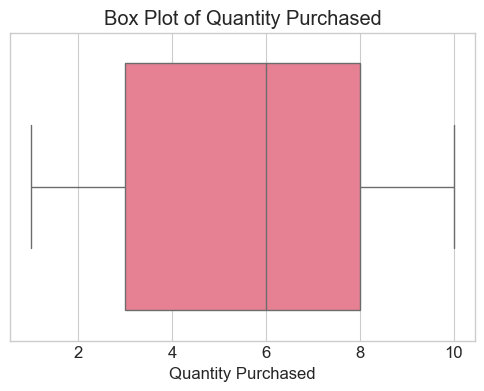

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Quantity'])

plt.title("Box Plot of Quantity Purchased")
plt.xlabel("Quantity Purchased")
plt.ylabel("")   

plt.show()

### Observation

• Median: The middle line in the box is at 6, indicating that 50% of transactions involve 6 or fewer items.

• Interquartile Range (IQR): The "box" spans from 4 to 8. This means the middle 50% of your customers buy between 4 and 8 items per trip.

• Range: The whiskers extend from 1 to 10. There are no visible outliers (dots) beyond the whiskers in this view.

### Explanation

• The data is symmetrical. Since the median is exactly in the center of the box, the distribution of quantity is likely "Normal" or uniform within the 1–10 range.

• The lack of outliers suggests that there are no "bulk buyers" or extreme wholesale-style transactions in this dataset; it is strictly retail-oriented.

### Insights

• Predictable Volume: Since most customers buy between 4 and 8 items, inventory management can be optimized for mid-sized baskets rather than single-item or bulk purchases.

• Cross-Selling Opportunity: Since the minimum is 1 and the median is 6, you have a healthy average. Marketing could focus on "bundle" offers to push that median from 6 toward 8.


## Total Spent

To identify the typical spending range per transaction and detect any high-value "outlier" purchases that skew the revenue.

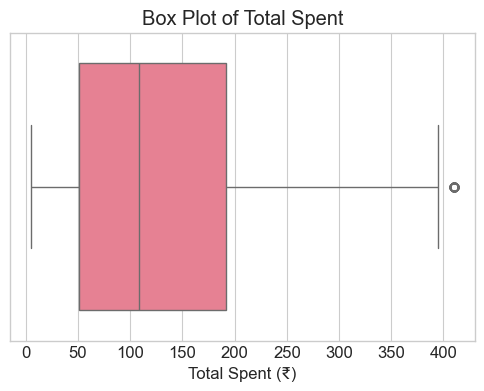

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Total Spent'])

plt.title("Box Plot of Total Spent")
plt.xlabel("Total Spent (₹)")
plt.ylabel("")   

plt.show()

### Observation

• Median Spend: The middle line in the box is roughly at 125, meaning 50% of transactions are below this value.

• Interquartile Range (IQR): Most customers spend between ~60 and ~200 per transaction.

• Outliers: There is at least one visible data point beyond the right whisker (near 400), representing a rare high-value transaction.

### Explanation

• The spending distribution is slightly right-skewed, as the whisker extends further toward the higher values (400) than the lower values.

• The "whiskers" indicate the typical boundaries of the data; anything beyond them is statistically unusual for this specific retail set.

### Insights

• Upselling Potential: Since the bulk of your revenue comes from the 60–200 range, marketing efforts should target moving the "Median" higher through bundled offers.

• Niche Premium Market: The outlier at 400 suggests a small segment of "big spenders" or premium product buyers that could be targeted with loyalty programs.


## Distribution of Price Per Unit

To determine the frequency of different price points across your inventory and identify if the store predominantly stocks budget-friendly, mid-range, or luxury items.


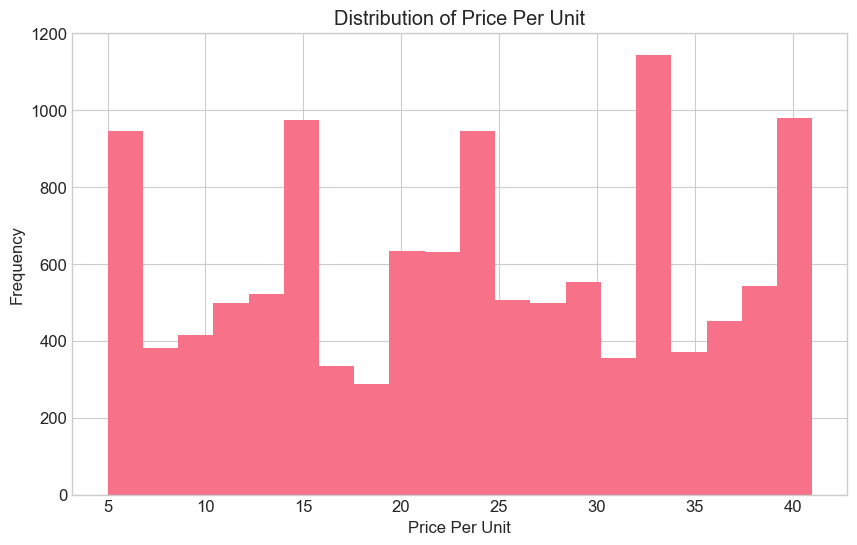

In [17]:
df['Price Per Unit'].hist(bins=20)
plt.title('Distribution of Price Per Unit')
plt.xlabel('Price Per Unit')
plt.ylabel('Frequency')
plt.show()

### Observation:

•	Price per unit values are spread roughly between 5 and 40.

•	Most products are concentrated in the low to mid price range.

•	Fewer products exist in the very high price range.

•	There are some peaks around mid-price values, meaning many products are priced there.

### Explanation:

•	The store mainly sells affordable to medium priced products.

•	Very high priced items are less in number.

•	The pricing strategy seems to focus on mass customer affordability.

### Insights:

• Since most products are low–mid price:

• Store targets regular daily customers.

• Mid price products have high frequency:

• These products may be best selling or high demand items.

• Less high price products:

• High price items may be niche or premium category.

• Business Action:

• Focus stock and marketing on mid price high demand products.
    
• Introduce selective premium products for higher revenue margin.

### Distribution of Quantity

analyze the distribution of the Quantity variable alone to understand how purchase quantities vary across transactions.

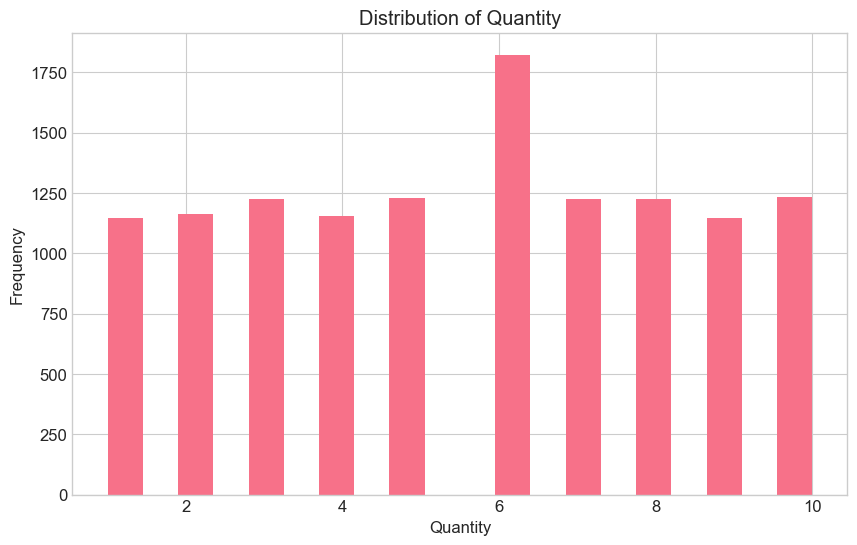

In [16]:
df['Quantity'].hist(bins=20)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

### Observation:

•	Quantity values range roughly from 1 to 10 units per purchase.

•	Most transactions happen in the mid quantity range.

•	There is a noticeable peak around quantity 6, meaning many customers buy around this amount.

•	Very low and very high quantities occur less frequently compared to mid range.


### Explanation

•   This chart shows how many items customers usually buy in one transaction.

•	Customers usually buy moderate number of items, not too low and not too high.
    
•	Quantity 6 looks like a common purchase pattern.
    
•	This indicates normal retail buying behavior (not bulk buying, not single item buying always).


### Insights

• Since mid quantities are common:

• Store should maintain good stock for frequently purchased items.

• Quantity peak around 5–7:

• Bundle offers or combo offers may work well.

• Low extreme bulk purchase:

• Business may focus more on regular customers than wholesale buyers.

• Business Action:

• Plan inventory based on average purchase quantity.
    
• Introduce small bulk offers (Buy 5–Get Discount type).


### Category Distribution

count the number of transactions in each product category to understand which categories are most and least popular in the retail dataset.


In [17]:
df['Category'].value_counts()

Category
Electric household essentials         1591
Furniture                             1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

### Observation
•	The number of records across all product categories is almost evenly distributed.

•	Electric household essentials and Furniture have the highest number of transactions (1,591 each).

•	Patisserie has the lowest number of records (1,528), but the difference is very small.

•	Overall, there is no significant category imbalance, which makes the dataset suitable for fair comparative analysis across categories.

### Explanation

• High Transaction Uniformity: The number of records per category is nearly identical, ranging from 1,528 to 1,591 transactions. This explains that customer interest is consistent across the entire store.

• The Revenue Driver: Despite the even traffic, Butchers and Electric household essentials lead in total revenue. This is explained by a higher Average Transaction Value (ATV)—customers spend more per purchase in these categories compared to low-cost staples like Milk Products.

• Payment Versatility: Sales are distributed across Cash, Credit Card, and Digital Wallets, ensuring that the revenue stream is not dependent on a single payment infrastructure.

### Insights

• The store exhibits a "Full-Basket" shopping behavior, where customers visit as frequently for luxury or durable goods (Electronics, Furniture) as they do for daily necessities (Food, Milk). Because transaction counts are so evenly spread, the store does not have "dead zones". The business is highly resilient; the narrow gap between the highest and lowest revenue categories means the company is protected against a crash in any single product sector.

• The path to growth lies in leveraging high-traffic, low-cost categories (like Patisserie or Milk) to trigger impulse buys for higher-margin items, as the customer base is already consistently present in those aisles.


### Payment Method Distribution

analyze how transactions are distributed across different payment methods (Cash, Card, UPI, etc.).


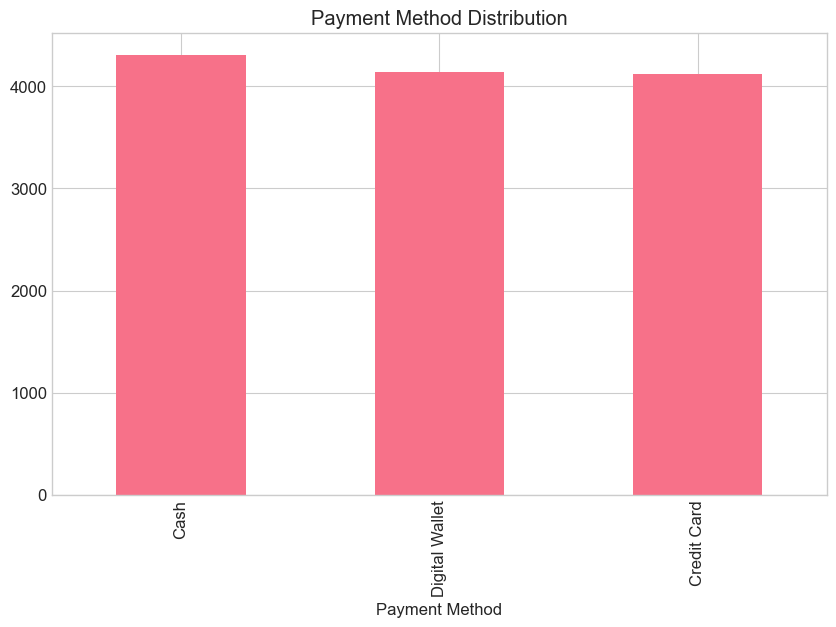

In [18]:
df['Payment Method'].value_counts().plot(kind='bar')
plt.title('Payment Method Distribution')
plt.show()

### Observation 

•	Three payment methods are used: Cash, Digital Wallet, Credit Card.

•	Cash transactions are slightly higher than other methods.

•	Digital Wallet and Credit Card usage are almost similar.

•	All payment methods are used widely by customers.

### Explanation

•   This chart shows customer payment preference distribution.

•	Customers are using both traditional (Cash) and digital payments.

•	Digital payment adoption is strong since wallet and card usage are close to cash.

•	Payment usage is well balanced across all methods.


### Insights

• Since all payment methods are used widely:

• Store should support all payment options.

• Slightly higher cash usage:

• Some customers still prefer offline/traditional payment.

• Strong digital payment usage:

• Opportunity to introduce digital offers (cashback, wallet offers).

• Business Action:

• Partner with digital wallet providers for offers.

• Maintain smooth POS and digital payment system.



## 3.3 Bivariate Analysis
Bivariate analysis explores the relationship between two variables to understand how one feature influences another in the retail sales dataset.
In this project, the focus is on understanding how different customer and product-related factors impact Total Spent (Sales Revenue) and Quantity Sold, which are the key performance indicators for a retail business.

### Purpose:
•   Understand how discounts are distributed across transactions.
  
•   Understand how sales change over time.

•   Understand how revenue is generated through different purchase channels.

•	Identify which factors contribute to higher or lower sales.

•	Discover purchasing patterns across product categories and payment methods.

•	Understand customer behavior to support data-driven business decisions.

•	Generate actionable insights for improving revenue and sales strategies.

### What We Analyze:

• Most frequently applied discounts , Relative proportion of each discount value , Detect unusually high or low discounts

• Monthly sales patterns to identify peak and low sales periods , Yearly sales patterns to see overall growth or decline ,Seasonal trends or           recurring patterns in revenue , Insights for inventory planning and marketing campaigns

• Total sales for In-store vs Online transactions

• Total sales(Total Spent)generated by each product category

• Relationship between Product Category and Total Sales
    
• Relationship between Payment Method and Total Sales

• Relationship between Quantity Purchased and Total Sales

• Relationship between Price Per Unit and Category Performance

• Impact of purchase quantity on overall revenue generation

## Discount vs Total Sales

To analyze how many transactions had discount applied vs not applied.

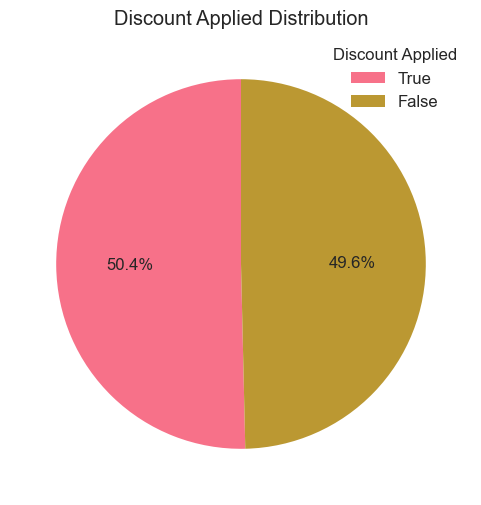

In [7]:
plt.figure(figsize=(6,6))

plt.pie(
    discount_counts,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Discount Applied Distribution")
plt.legend(discount_counts.index, title="Discount Applied")
plt.show()

### Observation

•	Approximately 50.4% of transactions had a discount applied.

•	Around 49.6% of transactions were completed without any discount.

•	The distribution is almost evenly split between discounted and non-discounted sales.

### Explanation

• The pie chart indicates that the business applies discounts in nearly half of all transactions. This suggests that discount strategies are used      regularly but not excessively. The near-equal distribution shows a balanced approach between promotional pricing and standard pricing.


### Insights

•	The company does not heavily rely only on discounts to generate sales.

•	Customers are willing to purchase even without discounts, indicating stable demand.

•	A balanced discount strategy helps maintain profit margins while still attracting price-sensitive customers.



## Monthly / Yearly Sales Trend

To analyze how sales change over time (monthly and yearly patterns)


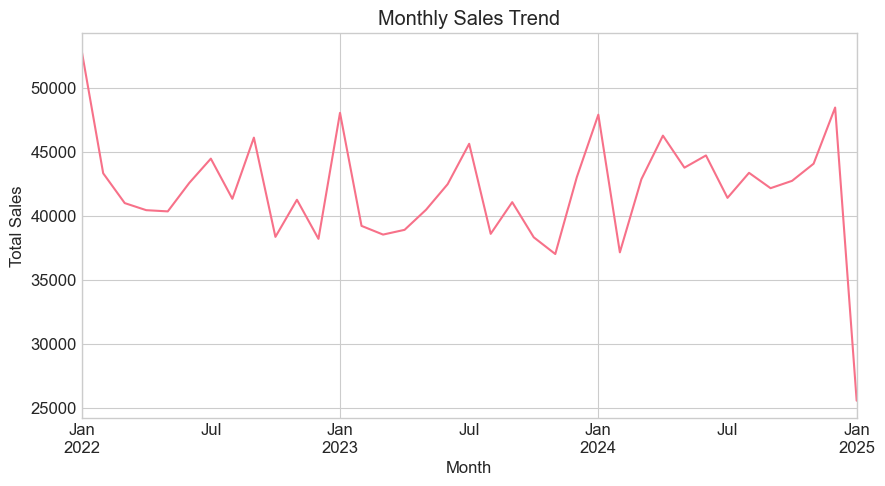

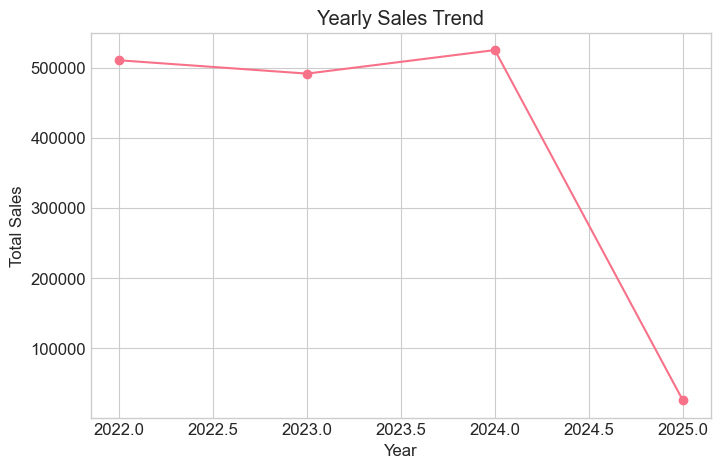

In [14]:
monthly_sales = df.groupby(
    df["Transaction Date"].dt.to_period("M")
)["Total Spent"].sum()

monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()
yearly_sales = df.groupby(
    df["Transaction Date"].dt.year
)["Total Spent"].sum()

yearly_sales.plot(kind="line", marker="o", figsize=(8,5))

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()


## Monthly Sales Trend:

### Observation

•	Monthly sales fluctuate between approx 37K – 52K

•	No strong continuous upward or downward trend

•	Some peak months show high sales spikes

•	Latest month shows sudden drop

### Explanation

•	Sales variation indicates seasonal demand changes

•	High peak months may be due to:

•	Festivals

•	Offers / discounts

•	Seasonal product demand

•	Sudden drop at end may be:

•	Incomplete month data

•   Fewer transactions recorded

•	Data collection cutoff


### Insights

•	Store has stable but seasonal revenue pattern

•	Marketing campaigns can be planned before peak months

•	Need to verify last month data accuracy

•	Opportunity to boost low months with promotions


## Yearly Sales Trend

### Observation

•	2022 → High sales (~5L+)

•	2023 → Slight decrease

•	2024 → Sales increased again

•	2025 → Huge drop (very low compared to other years)

### Explanation

•	Sales performance remained stable across 2022–2024

•	2024 may have strong promotions or higher demand

•	2025 drop likely due to:

•	Partial year data

•	Data not fully collected

•	New year started (only few months available)


### Insights

•	Business performance is generally stable year to year

•	2024 strategies can be studied and reused

•	2025 data should not be used for full-year comparison yet

•	Long-term growth opportunity exists with consistent marketing


## Location vs Sales Analysis

This will show which city/location generates more revenue.

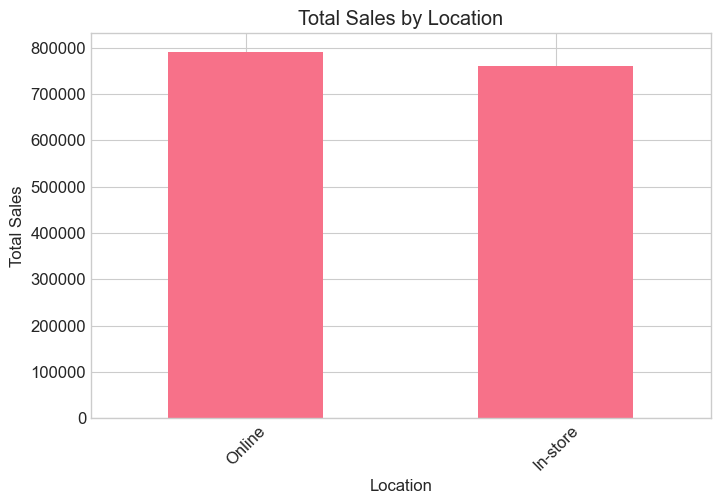

In [20]:
import matplotlib.pyplot as plt

location_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Location")
plt.xlabel("Location")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


In [22]:

location_sales = df.groupby("Location")["Total Spent"].sum().sort_values(ascending=False)
location_sales

Location
Online     791401.00
In-store   760670.00
Name: Total Spent, dtype: float64

### Observation

•	Online Sales ≈ 791,401

•	In-store Sales ≈ 760,670

•	Online sales are slightly higher than in-store sales.

•	Both channels are contributing almost equally to total revenue.

### Explanation


•	Customers are purchasing through both channels actively.

•	Online is slightly higher because:

•	Convenience of home delivery

•	Offers / discounts may be higher online

•	Wider product visibility online

•	In-store is still strong because:

•	Customers want physical product checking

•	Immediate purchase satisfaction

•	Trust factor in physical shopping


### Insights

•	Business has good omnichannel performance (Online + Store both strong).

•	Company should:

•	Continue investing in online marketing

•	Maintain store experience quality

•	Use online to push promotions

•	Use store to push premium / experience-based sales


## Total Spent by Category

aggregate total revenue for each product category and rank them from highest to lowest revenue contribution.

In [19]:
category_sales = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)
category_sales

Category
Butchers                             217397.00
Electric household essentials        213401.50
Beverages                            206617.50
Food                                 205684.00
Furniture                            205324.00
Computers and electric accessories   202353.50
Patisserie                           194540.50
Milk Products                        190877.50
Name: Total Spent, dtype: float64

### Observation
•	Butchers generates the highest total sales amount (217,397), making it the top-performing category in terms of revenue.

•	Electric household essentials is the second highest contributor to total spending, indicating strong demand for essential electronic items.

•	Beverages, Food, and Furniture show similar total spending values, suggesting consistent customer purchasing behavior across these categories.

•	Milk Products has the lowest total spending (190,877.5), despite having a comparable number of transactions.

•	Overall, spending is fairly distributed across categories, with no extreme outliers, indicating stable and diversified sales performance.

### Explanation

• Necessity vs. Discretionary Spending: The top categories—Butchers, Electric household essentials, and Beverages—represent "high-frequency" or "high-necessity" items. Meat and beverages are grocery staples bought weekly, while household essentials often carry a higher individual price tag (average transaction value), which helps them keep pace with high-volume grocery items.

• Price Point Distribution: Milk Products and Patisserie are at the bottom, likely because they have lower unit prices compared to a vacuum cleaner (essentials) or a large cut of meat (butchers). Even if you sell many units of milk, the "Total Spent" will struggle to overtake categories with higher-priced goods.

• Stable Demand: The tight range of values (roughly $190k to $217k) suggests a very "mature" retail environment where customer traffic is consistent across the store rather than being driven by a single niche.

### Insights


• The data reveals a highly stable and diversified retail ecosystem. Rather than being dependent on a single "hero" product, revenue is remarkably     well-balanced across all departments, with total spending per category staying within a narrow range of approximately $190k to $217k.

  Key Takeaways:

• Resilient Business Model: The consistent spending across categories—from perishables like Butchers to durables like Electric household essentials—   indicates a "full-basket" shopping habit where customers fulfill multiple household needs in a single visit.

• Low-Risk Revenue Stream: Because there are no extreme outliers or failing departments, the business is well-protected against sector-specific        downturns.

• Strategic Stability: Even the "lowest" performing category (Milk Products) maintains a strong baseline of over $190k, suggesting that lower-priced    staples still drive significant volume and consistent customer traffic.

• Growth Opportunity: Since the revenue gap between the top and bottom categories is small, the primary growth lever is not "fixing"                   underperformers, but rather using high-traffic categories (like Butchers and Beverages) to cross-promote higher-margin items (like Electronics and   Furniture).



## Total Sales by Category

analyze how total sales revenue is distributed across different product categories.


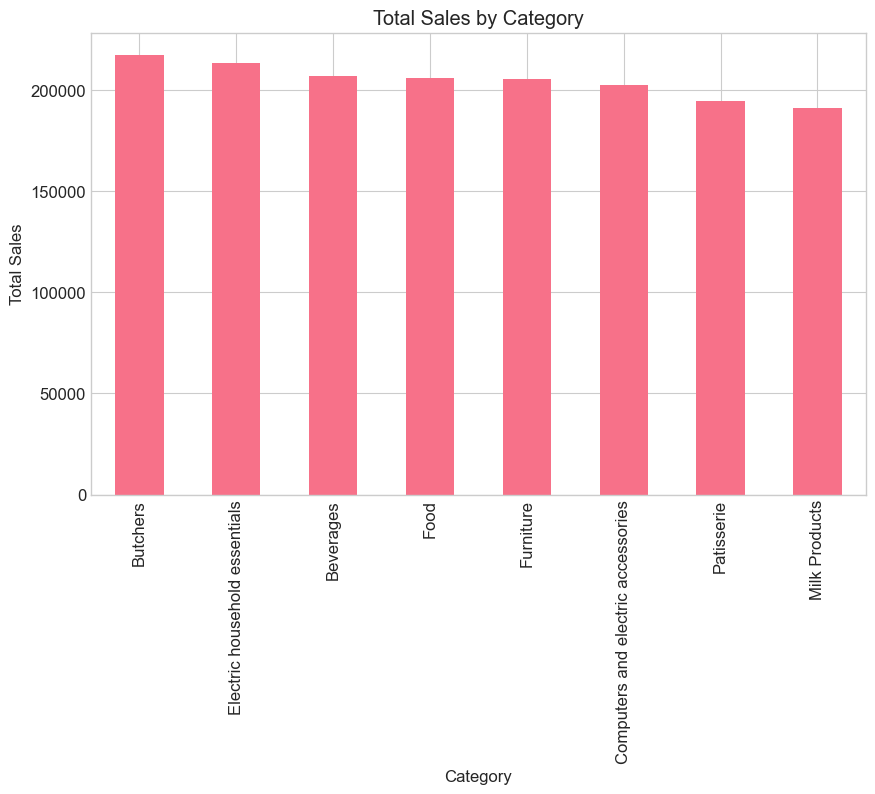

In [5]:
category_sales = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

### Observation

•	Total sales are almost evenly distributed across all categories.

•	Some categories show slightly higher sales than others, but difference is small.

•	No single category is extremely dominating or extremely low.

•	Categories like Butchers / Household / Beverages look slightly higher (small difference)

### Explanation

•  This chart compares how much revenue each category generates.

•	The store revenue is well balanced across multiple categories.

•	Business is not dependent on only one category.

•	Customer demand exists across many product types.


### Insights

• Balanced category sales:

• Business risk is lower (not dependent on one product type).

• Multiple strong categories:

• Store should maintain inventory across all major categories.

• Slightly higher performing categories:

• These can be promoted more for extra revenue growth.

• Business Action:

• Maintain variety of products.

• Focus marketing on slightly higher performing categories.


## Payment Method vs Total Sales

analyze and compare the total revenue generated through each payment method.

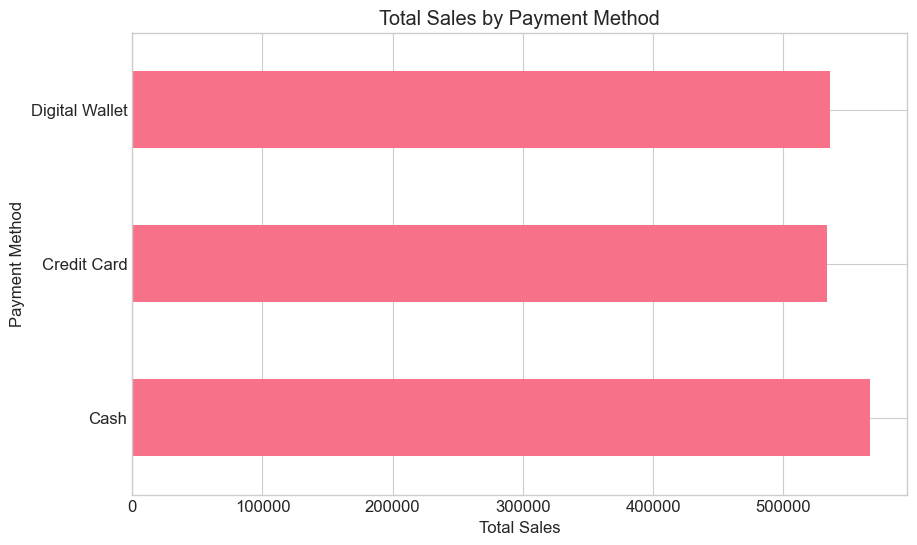

In [7]:
payment_sales.plot(kind='barh')
plt.title('Total Sales by Payment Method')
plt.xlabel('Total Sales')
plt.ylabel('Payment Method')
plt.show()

### Observation

•	Cash, Credit Card, and Digital Wallet sales are almost equal.

•	Cash looks slightly higher than others.

•	Digital Wallet and Credit Card are very close to each other.

•	No payment method is extremely low.


### Explanation

This shows how customers prefer to pay.

•	Customers are using all payment methods.

•	Store is not dependent on only cash or only digital payment.

•	Digital adoption is also strong.



### Insights


• Payment flexibility is good

• Customers can pay how they like.

• Digital payments are strong

• Good sign for modern retail trend.

• Cash still important

• Cannot remove cash option.

• Business Action

• Keep all payment options active

• Promote digital wallet offers for future growth


## Quantity vs Total Sales

analyze the relationship between number of items purchased (Quantity) and total sales value.

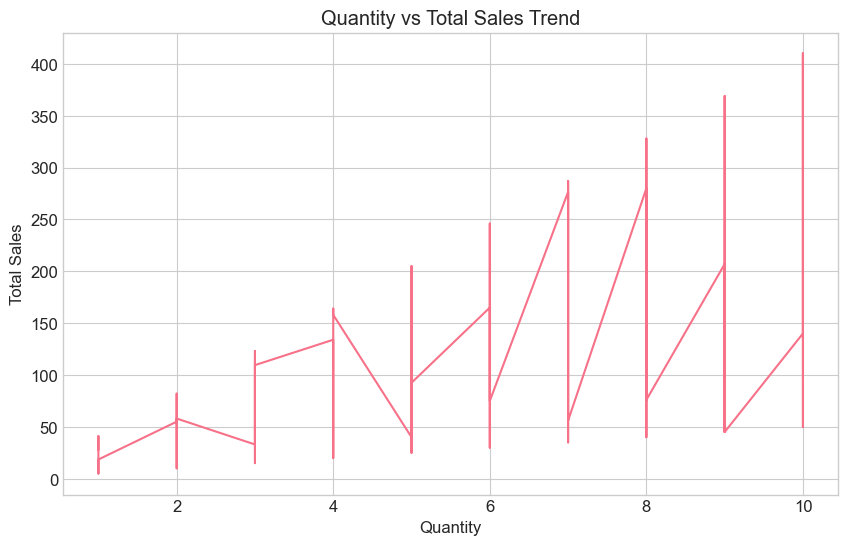

In [9]:
df_sorted = df.sort_values('Quantity')

plt.plot(df_sorted['Quantity'], df_sorted['Total Spent'])
plt.title('Quantity vs Total Sales Trend')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.show()

### Observation

•	When quantity increases, total sales also generally increase.

•	There are some ups and downs (not perfectly straight line).

•	Higher quantities (8, 9, 10) show higher sales values.

•	Lower quantities show lower total sales.

### Explanation

 This shows relationship between:

• Number of items purchased

• Total revenue generated

• Buying more items → More revenue

• Quantity directly affects sales value


### Insights

• Strong positive relationship

• More items sold = More revenue

• Bulk purchase customers are valuable

• Should encourage bulk buying

• Business Action

• Offer combo offers
    
• Offer bulk discounts
    
• Promote “Buy More Save More”


## Price Per Unit vs Total Sales

analyze how product price per unit influences total sales revenue.


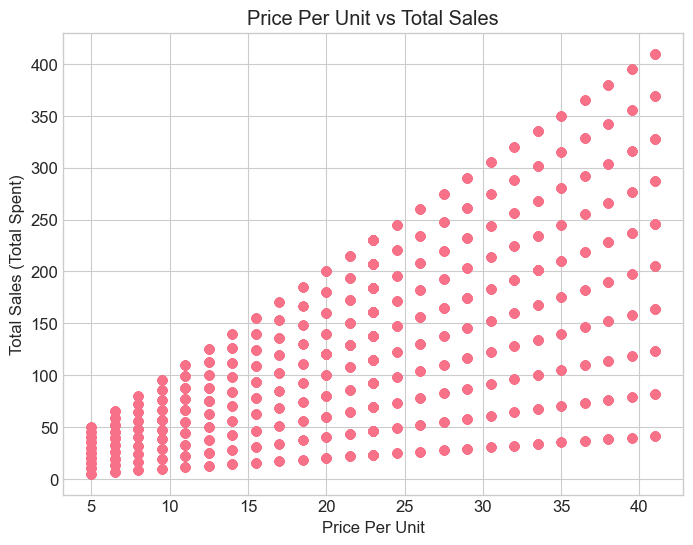

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["Price Per Unit"], df["Total Spent"])
plt.xlabel("Price Per Unit")
plt.ylabel("Total Sales (Total Spent)")
plt.title("Price Per Unit vs Total Sales")
plt.show()

### Observation

•	As Price Per Unit increases, Total Sales value also increases.

•	Dots move upward when price increases.

•	Higher price items generate higher bill value.

### Explanation

 This shows relationship between:

• Product price

• Total amount customer spends

  Total Sales = Price × Quantity

  If price is higher → bill amount becomes higher.


### Insights


•  High price products give high revenue per sale

•  Premium products are important for profit

•  Business Action Ideas

•	Promote premium product categories

•	Maintain good stock for high price items

•	Upsell higher price products



## Impact of Purchase Quantity on Overall Revenue Generation

analyze how the number of items purchased affects the overall revenue generated by the retail store.

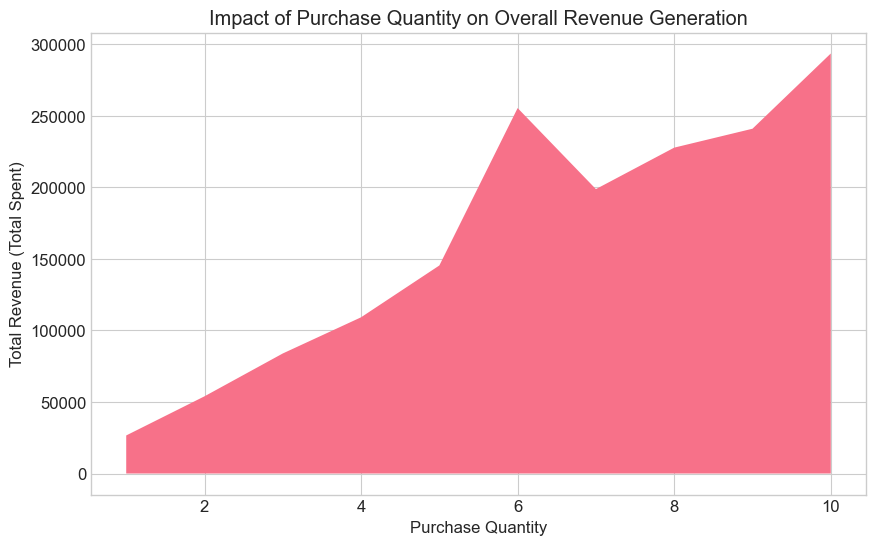

In [8]:
import matplotlib.pyplot as plt

qty_revenue = df.groupby("Quantity")["Total Spent"].sum().reset_index()

plt.figure(figsize=(10,6))
plt.fill_between(qty_revenue["Quantity"], qty_revenue["Total Spent"])
plt.xlabel("Purchase Quantity")
plt.ylabel("Total Revenue (Total Spent)")
plt.title("Impact of Purchase Quantity on Overall Revenue Generation")
plt.show()

### Observation

•	When Purchase Quantity increases, Total Revenue also increases.

•	Small dip may appear at some points → but overall trend is upward.

•	Low quantity → low revenue.

•	High quantity → high revenue.

### Explanation

Revenue depends mainly on:

• Number of items sold

• Price per item
  
  If customers buy more quantity → Total bill value increases → Revenue increases.


### Insights

• Bulk purchase customers are important for revenue growth

• Business can increase revenue by:

• Giving combo offers

• Giving bulk purchase discounts

• Encouraging multi-item purchase

• Focus marketing on customers who buy multiple items.



## 3.4 Multivariate Analysis

• Multivariate analysis is the process of analyzing the relationship between three or more variables at the same time.  

• It helps in understanding how multiple factors together affect business outcomes like total sales and revenue.

• In retail sales analysis, multivariate analysis helps to study how product category, quantity purchased, price per unit, and payment method          together influence total sales.


### Purpose:

• The main purpose of multivariate analysis is to understand the combined impact of multiple variables on business performance.  

• It helps identify complex patterns, improve decision-making, and support sales strategy planning.

• It also helps businesses understand which combination of factors generates higher revenue.


### What We Analyze:

• Relationship between Product Category, Quantity Purchased, and Total Sales
  
• Relationship between Product Category, Price Per Unit, and Total Sales

    

## Category vs Payment Method vs Total Sales

analyze how total sales are influenced by the combination of product category and payment method.

In [5]:
pd.pivot_table(
    df,
    values='Total Spent',
    index='Category',
    columns='Payment Method',
    aggfunc='sum'
)

Payment Method,Cash,Credit Card,Digital Wallet
Category,,,
Beverages,70249.50,61310.50,65487.50
Butchers,72638.00,72832.50,62647.50
Computers and electric accessories,68063.00,63348.00,59281.50
Electric household essentials,68011.00,60514.00,75288.50
Food,69710.00,63540.50,61561.50
Furniture,67565.00,64779.00,62966.00
Milk Products,59882.00,60822.00,59408.00
Patisserie,61591.50,59935.50,60638.50


### Observation

• Uniformity: Sales are remarkably consistent across categories. Most cells hover around the $60,000 to $70,000 range. There are no extreme "underperforming" categories.

• High Performers:  Electric household essentials via Digital Wallet is the highest single cell in the table ($75,288.50).

• Butchers shows high performance across all payment methods, consistently staying above $62k.

• Low Performers: Milk Products and Patisserie tend to sit at the lower end of the spectrum, often dipping just below the $60k mark.

### Explanation

• Consumer Behavior: The high "Electric household essentials" value for Digital Wallets suggests that tech-savvy customers or those making larger       planned purchases prefer digital payment platforms—perhaps due to cashback offers or ease of online/app-based tracking.

• Transaction Frequency: Categories like Butchers and Beverages having high "Cash" totals likely reflects "routine" or "daily" shopping habits where    people still feel comfortable using physical currency for groceries.

• Data Balance: The close proximity of all values suggests a well-distributed dataset or a store that has successfully diversified its inventory to     meet broad demand.


### Insights

• Targeted Promotions: Since Electric household essentials performs best with Digital Wallets, you could run a "10% off with Digital Wallet"           campaign for lower-performing categories like Patisserie to see if it drives a similar volume.

• Inventory Focus: Butchers and Beverages are your "anchors." They bring in high revenue regardless of how the customer pays. Ensure these sections    are always well-stocked and placed prominently in the store layout.

• Payment Optimization: Since Credit Card sales are slightly lower in some high-volume categories (like Beverages), there might be an opportunity to   partner with banks for reward points on grocery spend to capture more of that market share.


## Category + Quantity +Total Sales

To analyze how product category and purchase quantity together impact total sales.


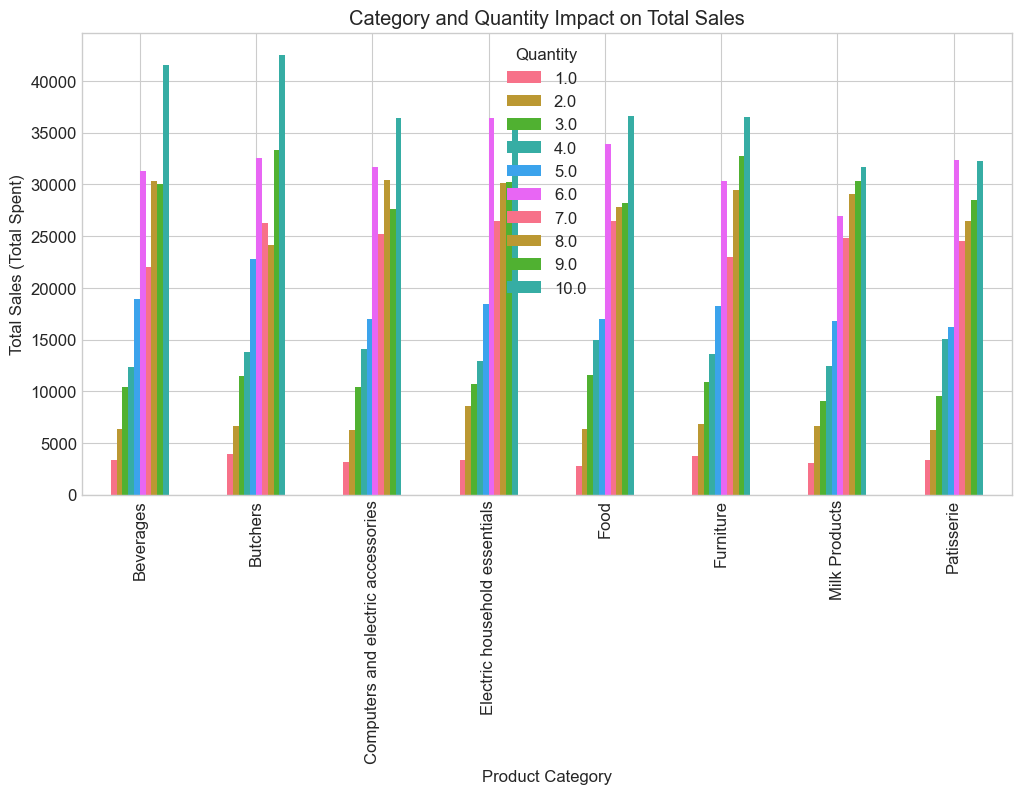

In [17]:
import matplotlib.pyplot as plt

multi_data = df.groupby(["Category", "Quantity"])["Total Spent"].sum().unstack()

multi_data.plot(kind="bar", figsize=(12,6))

plt.xlabel("Product Category")
plt.ylabel("Total Sales (Total Spent)")
plt.title("Category and Quantity Impact on Total Sales")
plt.show()

### Observation

•	In all categories, when quantity increases → Total Sales increases.

•	Some categories generate higher sales at same quantity level.

•	Higher quantity levels (8–10) show highest sales values.

•	Low quantity (1–3) shows low sales in all categories.

### Explanation

• When customers buy more quantity → total bill increases.

• Some categories may have:

• Higher demand

• Higher price items

• More frequent purchase

• So even at same quantity → sales differ by category.

### Insights

• Encourage bulk purchase → Sales will increase.

• Focus marketing on:

• High performing categories

• High demand products

• Offer:

• Combo offers

• Bulk discounts

• Buy More Save More offers

• Identify strongest revenue categories → Invest more there.


## Category + Price Per Unit +Total Sales

To analyze how product category and price per unit together influence total sales.


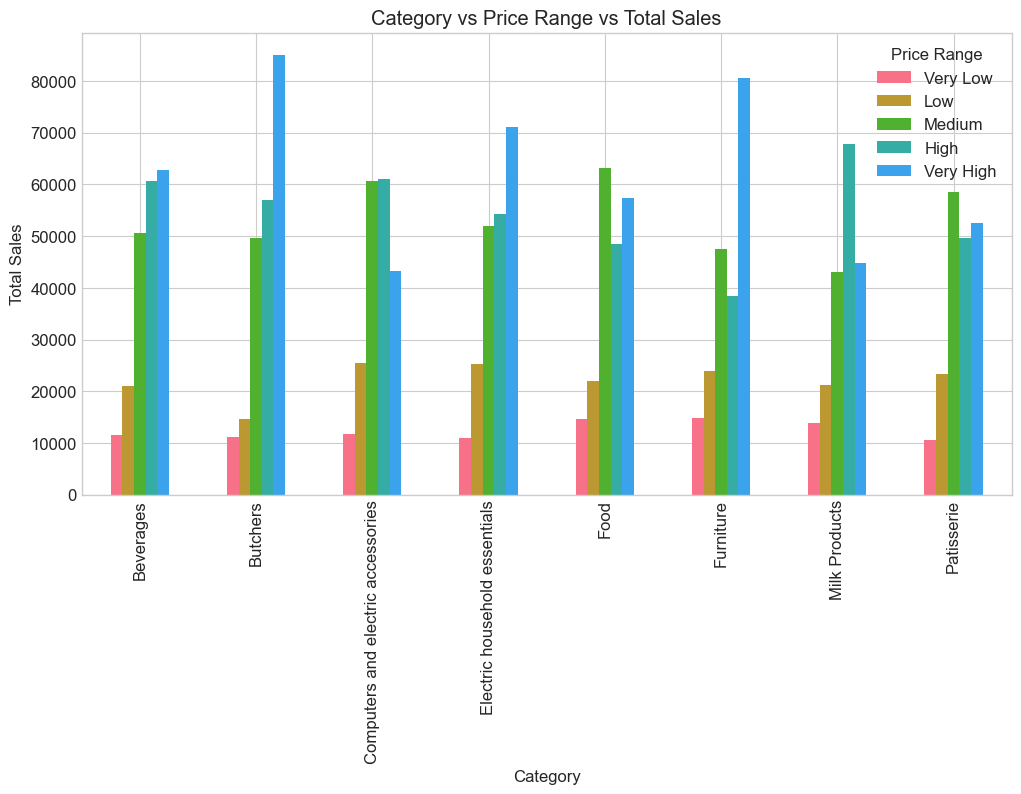

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df["Price Range"] = pd.cut(
    df["Price Per Unit"],
    bins=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

multi_price = df.groupby(["Category", "Price Range"])["Total Spent"].sum().unstack()

multi_price.plot(kind="bar", figsize=(12,6))

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Category vs Price Range vs Total Sales")
plt.show()

### Observation

• Very Low price range → Lowest total sales.
  
• Medium to High price range → Higher total sales.

  
• Very High price range → Highest sales in some categories.

  
• Some categories perform strongly across all price ranges.

  
• Categories like Butchers / Furniture / Milk Products show strong high-price sales.


### Explanation

• Higher price products increase total bill value.

• Customers may:
 
• Buy premium products

• Trust quality brands

• Spend more in essential categories

• Some categories naturally have higher priced products (example: electronics, furniture, premium food items).


### Insights

• High price range products are major revenue drivers.

• Business should:

• Maintain stock for high price products

• Promote premium category products

• Target customers who buy premium products

• Use pricing strategy:

• Bundle medium + high price products

• Offer premium product marketing campaigns


## 3.5 Correlation Aanlysis

Check relationship strength between numbers
Only numeric columns like:

•	Quantity
    
•	Price
    
•	Total Sales
    
•	Discount
    
•	Profit

### purpose:
•   Strong relationship
    
•	Weak relationship
    
•	Positive relation
    
•	Negative relation

### What We Analyze:

• How category affects sales

• How quantity + category together affect sales

• How price + category together affect sales

• Discount Effectiveness
    

## Correlation Matrix

measure and analyze the strength and direction of relationships between numerical variables in the dataset.

In [7]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
corr_matrix

,Price Per Unit,Quantity,Total Spent
Price Per Unit,1.00,0.01,0.63
Quantity,0.01,1.00,0.71
Total Spent,0.63,0.71,1.00


## Heatmap Visualization

visually represent the correlation between numerical variables using colors for easy understanding.

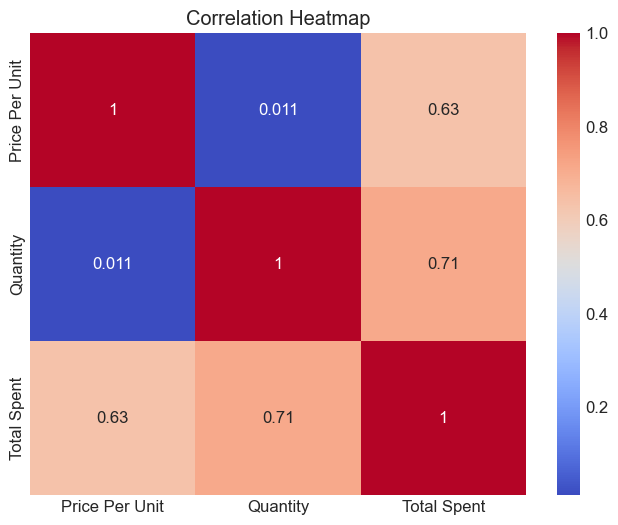

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Observation

•	Price Per Unit vs Quantity → 0.011 (Very Low)

•	Price Per Unit vs Total Spent → 0.63 (Moderate Positive)

•	Quantity vs Total Spent → 0.71 (Strong Positive)

### Explanation

🔹 Price vs Quantity (0.011)

• Almost no relationship
• Price change does not affect how much quantity customers buy

  Meaning:
  Customers buy based on need, not price.

⸻

🔹 Price vs Total Spent (0.63)

• Moderate relationship
• Higher price → Higher total bill

Meaning:
Expensive items increase total sales value.

⸻

🔹 Quantity vs Total Spent (0.71)

• Strong relationship
• More quantity → More total spending

Meaning:
Bulk purchase customers contribute more revenue.


### Insights

• Main Sales Driver → Quantity Purchased

• Increasing quantity sales increases revenue strongly.
• Secondary Driver → Price Per Unit

• Premium products also help increase total sales.

• Customer Behavior Insight

• Customers are not very price sensitive (since price vs quantity is very low).


## Discount vs Total Sales Analysis

To analyze the relationship between Discount offered and Total Sales generated using correlation analysis.


In [25]:
# Calculate correlation between Discount Applied and Total Spent
correlation = df["Discount Applied"].corr(df["Total Spent"])

print("Correlation between Discount Applied and Total Sales:", correlation)

Correlation between Discount Applied and Total Sales: 0.0028466468918293317


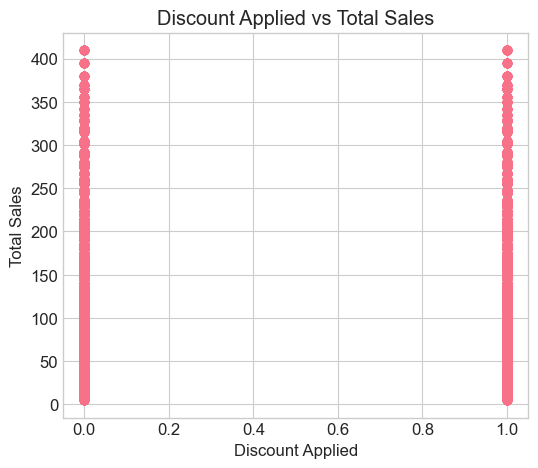

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(df["Discount Applied"], df["Total Spent"])

plt.title("Discount Applied vs Total Sales")
plt.xlabel("Discount Applied")
plt.ylabel("Total Sales")
plt.show()

### Observation

• Correlation Value: The calculated Pearson correlation coefficient is approximately 0.0028.

• Data Distribution: The scatter plot shows two distinct vertical columns of data points: one at 0.0 (no discount) and one at 1.0 (full discount or a binary discount flag).

• Visual Trend: There is no visible upward or downward slope. The spread of "Total Sales" is almost identical regardless of whether a discount was applied or not.

### Explanation

• Near-Zero Correlation: A correlation of 0.0028 is statistically negligible. In data science, this indicates that there is no linear relationship     between the discount offered and the total sales amount in this specific dataset.

• Binary Nature of Data: The "Discount Applied" variable appears to be categorical/boolean (0 or 1) rather than a continuous range (like 5%, 10%,      15%). This often makes a standard Pearson correlation less meaningful than a comparison of means (like a T-test).

• Independent Variance: The fact that "Total Sales" ranges from 0 to 400 in both categories suggests that other factors (like item price or            quantity) are driving the sales volume much more than the discount itself.

### Insights

• Discount Ineffectiveness: The data suggests that applying a discount is not currently driving higher-value transactions. Customers are spending      similar amounts whether they get a discount or not.

• Non-Price Sensitive Customers: This reinforces your earlier note in the notebook: "Customers are not very price sensitive." Since sales volume       doesn't spike when a discount is present, your customer base likely values the product itself or the brand over the "deal."

• Potential Data Issue: If "Discount Applied" is supposed to be a percentage (e.g., 0.1 for 10%), the current plot suggests you only have data for     "No Discount" and "100% Discount," which might indicate a data entry error or a need for more granular data.
